## Evaluación de los modelos

Este notebook evalúa diferentes modelos de machine learning entrenados para la detección de fraude, comparando su rendimiento usando métricas balanceadas y un score compuesto que considera tanto la precisión como la eficiencia computacional.## Evualuacion de los modelos

In [1]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt


from sklearn.metrics import (
    balanced_accuracy_score, 
    classification_report, 
    roc_auc_score, 
    roc_curve
)

from utils.model import load_multiple_models, save_best_model
from constants.separated import X_val, y_val
from constants.scaled import X_val_scaled, y_val_scaled



import seaborn as sns 


## Carga de modelos

Cargamos los modelos previamente entrenados para su evaluación.Cargamos los modelos

In [2]:
model_names = ["rf1", "rf2", "rf3", "rf4", "rf5", "rf6", "xgb1", "xgb2"]
models = load_multiple_models(model_names)

## Preparación de datos para evaluación

Definimos los diccionarios de datos para evaluar cada modelo con su correspondiente conjunto de datos (escalados o no escalados).Procedemos a evaular los modelos con balanced_accuracy_score

In [3]:
X_dict = {
    # Original data models
    "rf1": X_val, 
    "rf2": X_val, 
    "rf3": X_val,
    "xgb1": X_val,
    # Scaled data models  
    "rf4": X_val_scaled,
    "rf5": X_val_scaled, 
    "rf6": X_val_scaled,
    "xgb2": X_val_scaled
}

y_dict = {
    # Original data models
    "rf1": y_val,
    "rf2": y_val,
    "rf3": y_val,
    "xgb1": y_val,
    # Scaled data models
    "rf4": y_val_scaled,
    "rf5": y_val_scaled,
    "rf6": y_val_scaled,
    "xgb2": y_val_scaled
}

## Score Compuesto

Definimos una función para calcular un score compuesto que equilibra precisión y eficiencia:

1. Equilibrio de Métricas:
   - 60% peso para precisión balanceada
   - 40% peso para velocidad de convergencia

2. Normalización de Convergencia:
   - Usa función exponencial negativa para penalizar modelos que requieren muchas iteraciones
   - Mantiene escala comparable con la precisión balanceada

3. Ventajas:
   - Identifica modelos con buen balance entre precisión y eficiencia
   - Penaliza modelos que requieren recursos excesivos
   - Permite comparación directa entre diferentes tipos de modelos

In [4]:
def calculate_composite_score(
    accuracy: float, 
    convergence_iterations: int, 
    accuracy_weight: float = 0.7, 
    convergence_weight: float = 0.3
) -> float:
    normalized_convergence = np.exp(-convergence_iterations/100)
    return (accuracy_weight * accuracy) + (convergence_weight * normalized_convergence)

## Evaluación de Modelos

Evaluamos cada modelo calculando:
- Precisión balanceada
- Score AUC-ROC
- Reporte de clasificación detallado
- Score compuestoEvaluamos los modelos con el nuevo score compuesto

In [5]:
def evaluate_model(model, X, y, model_name: str) -> dict:
    # Predictions
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    
    # Calculate metrics
    bal_acc = balanced_accuracy_score(y, y_pred)
    auc = roc_auc_score(y, y_proba)
    
    # Get convergence metric based on model type
    if model_name.startswith('rf'):
        convergence_metric = len(model.estimators_)
        convergence_type = "trees"
    elif model_name.startswith('xgb'):
        convergence_metric = model.n_estimators  # For XGBoost we use n_estimators
        convergence_type = "boosting rounds"
    else:
        convergence_metric = model.n_iter_[0]  # For other models like LogisticRegression
        convergence_type = "iterations"
    
    # Calculate composite score
    composite_score = calculate_composite_score(bal_acc, convergence_metric)
    
    return {
        "balanced_accuracy": bal_acc,
        "auc": auc,
        "convergence_metric": convergence_metric,
        "convergence_type": convergence_type,
        "composite_score": composite_score,
        "classification_report": classification_report(y, y_pred)
    }

In [6]:
# Evaluate all models
results = {}
for name, model in models.items():
    print(f"\nEvaluando {name}:")
    print("-" * 50)
    
    # Evaluate model
    eval_results = evaluate_model(model, X_dict[name], y_dict[name], name)
    results[name] = eval_results
    
    # Print results
    print(f"Balanced Accuracy: {eval_results['balanced_accuracy']:.4f}")
    print(f"Convergence ({eval_results['convergence_type']}): {eval_results['convergence_metric']}")
    print(f"Composite Score: {eval_results['composite_score']:.4f}")
    print(f"AUC: {eval_results['auc']:.4f}")
    print("\nClassification Report:")
    print(eval_results['classification_report'])


Evaluando rf1:
--------------------------------------------------
Balanced Accuracy: 0.8538
Convergence (trees): 100
Composite Score: 0.7080
AUC: 0.9776

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     38059
           1       0.94      0.71      0.81      1223

    accuracy                           0.99     39282
   macro avg       0.97      0.85      0.90     39282
weighted avg       0.99      0.99      0.99     39282


Evaluando rf2:
--------------------------------------------------
Balanced Accuracy: 0.8918
Convergence (trees): 200
Composite Score: 0.6648
AUC: 0.9568

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     38059
           1       0.63      0.80      0.70      1223

    accuracy                           0.98     39282
   macro avg       0.81      0.89      0.85     39282
weighted avg       0.98      0.98      0.98  

## Visualización de Resultados

Generamos gráficos comparativos de los diferentes modelos evaluados.

C:\Users\smithinator\AppData\Local\Temp\ipykernel_4172\1037181413.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(names, rotation=45)
C:\Users\smithinator\AppData\Local\Temp\ipykernel_4172\1037181413.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(names, rotation=45)
C:\Users\smithinator\AppData\Local\Temp\ipykernel_4172\1037181413.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(names, rotation=45)
C:\Users\smithinator\AppData\Local\Temp\ipykernel_4172\1037181413.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(names, rotation=45)


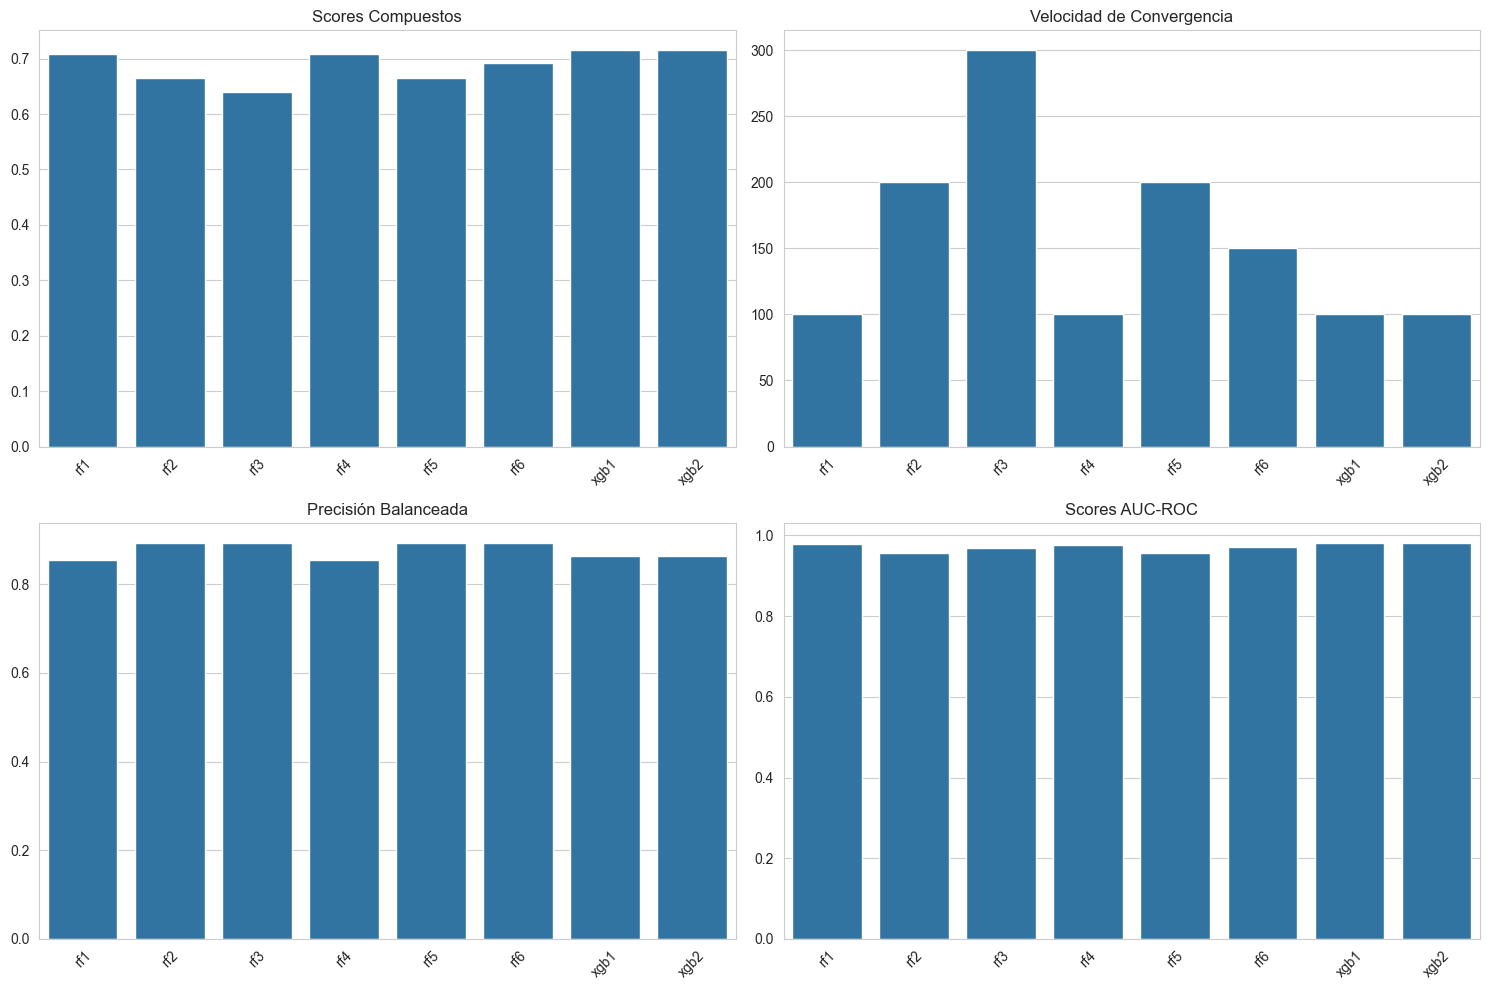

In [7]:
def plot_model_comparison(results: dict) -> None:
    # Set the style using seaborn
    sns.set_style("whitegrid")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    names = list(results.keys())
    
    # Plot 1: Composite Scores
    scores = [results[name]['composite_score'] for name in names]
    sns.barplot(x=names, y=scores, ax=axes[0,0])
    axes[0,0].set_title('Scores Compuestos')
    axes[0,0].set_xticklabels(names, rotation=45)
    
    # Plot 2: Convergence
    convergence = [results[name]['convergence_metric'] for name in names]
    sns.barplot(x=names, y=convergence, ax=axes[0,1])
    axes[0,1].set_title('Velocidad de Convergencia')
    axes[0,1].set_xticklabels(names, rotation=45)
    
    # Plot 3: Balanced Accuracy
    accuracies = [results[name]['balanced_accuracy'] for name in names]
    sns.barplot(x=names, y=accuracies, ax=axes[1,0])
    axes[1,0].set_title('Precisión Balanceada')
    axes[1,0].set_xticklabels(names, rotation=45)
    
    # Plot 4: AUC Scores
    auc_scores = [results[name]['auc'] for name in names]
    sns.barplot(x=names, y=auc_scores, ax=axes[1,1])
    axes[1,1].set_title('Scores AUC-ROC')
    axes[1,1].set_xticklabels(names, rotation=45)
    
    plt.tight_layout()
    plt.show()

# Generate plots
plot_model_comparison(results)

## Selección del Mejor Modelo

Identificamos y guardamos el modelo con mejor desempeño según el score compuesto.

In [8]:
best_model_name = max(results.items(), key=lambda x: x[1]["composite_score"])[0]
best_result = results[best_model_name]

print("\n=== Mejor Modelo Basado en Precisión y Convergencia ===")
print(f"Mejor Modelo: {best_model_name}")
print(f"Score Compuesto: {best_result['composite_score']:.4f}")
print(f"Precisión Balanceada: {best_result['balanced_accuracy']:.4f}")
print(f"Convergencia ({best_result['convergence_type']}): {best_result['convergence_metric']}")


=== Mejor Modelo Basado en Precisión y Convergencia ===
Mejor Modelo: xgb1
Score Compuesto: 0.7152
Precisión Balanceada: 0.8640
Convergencia (boosting rounds): 100


Guardamos el mejor modelo para optimizarlo

In [9]:
save_path = save_best_model(models[best_model_name], best_model_name)
print(f"\nMejor modelo guardado en: {save_path}")


Mejor modelo guardado en: ./best_model\xgb1.joblib
